# Plot Operations Module 
- `plot_operations`



# Contents

1. Module Overview

2. PLot Operations (`plot.py`)
- image_row()
- image_grid()
- bbox()
- segment()

3. Summary

# Imports

In [1]:
import cvcore  as cr
import json
import numpy as np
import cv2

In [2]:
dog=cr.image_operations.io.load_image("../assets/g.jpg")
cat=cr.image_operations.io.load_image("../assets/cat.jpg")
test1=cr.image_operations.io.load_image("../assets/a.jpg")


# Module Overview : `plot_operations`
- This module is made for visulization purpose internally using matplotlib.pyplot to plot and display images as per the function it has been passed to .
- This provides function to -
1. To display image in single horizontal row                                    `image_row()`
2. To display image in grid with desired row and coloumn                        `image_grid()`
3. To display image with the specified bbox                                    `bbox()`
4. To diaplay segment based on the masks with bbox or wtihout bbox             `segment()` 

### `image_row()`

**Purpose**

Displays image in a single horizontal row.

**Parameters**
1. **images - keyword argument  
    - it is in the form of dictionary 

**Demonstration**

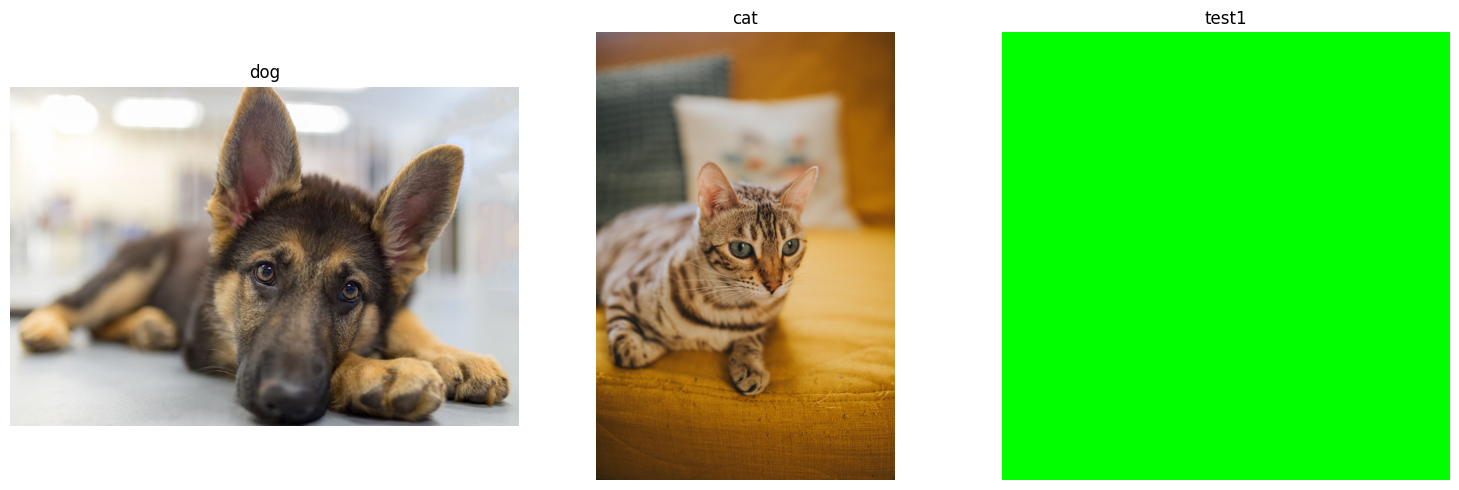

In [3]:
cr.plot_operations.image_row(
    dog=dog,
    cat=cat,
    test1=test1,
)


### `image_grid()`

**Purpose**

Displays multiple images with specified grid (row,col).

**Parameters**
1. images = list or tuple of images
2. row = row of the grid
3. col = coloumn of the grid
4. titles = list or tuple of titles that are to given to the images

**Demonstration**

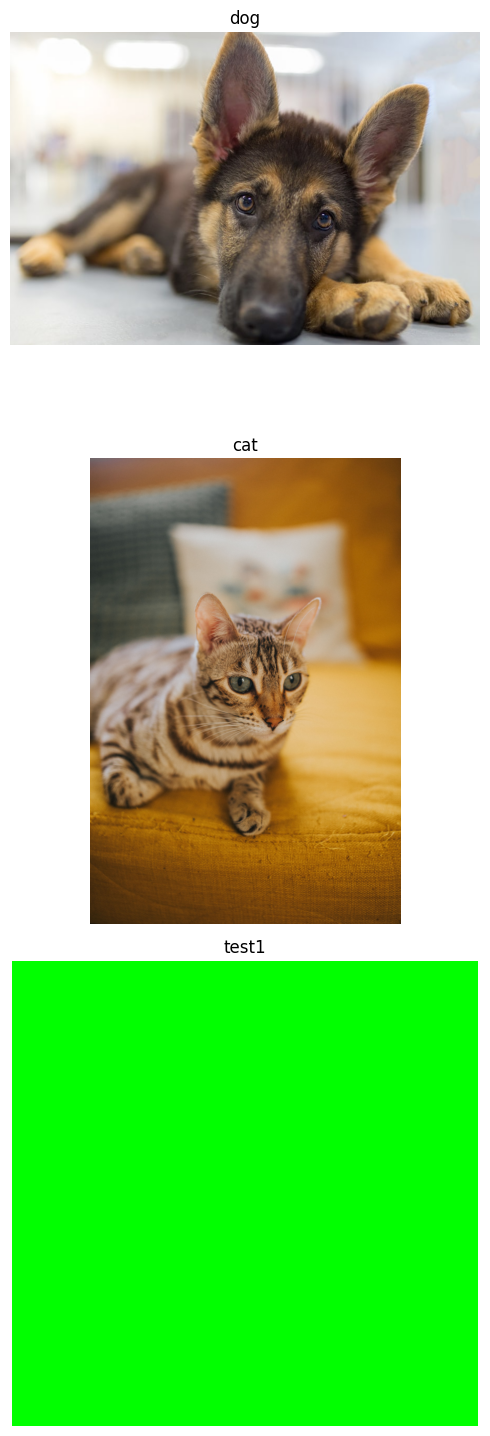

In [4]:
cr.plot_operations.image_grid(images=[dog, cat, test1], titles=["dog","cat","test1"], rows=3, cols=1)

### `bbox()`

**Purpose**

Display an image with annotated bounding boxes.

**Parameters**

- image : numpy.ndarray, str, or pathlib.Path
        Input image. Can be:
        - numpy.ndarray
        - str (image path)
        - pathlib.Path

- bboxes : list or tuple
        Collection of bounding boxes in the format:
        [[x, y, width, height], ...]
- labels : list or tuple
        Labels corresponding to each bounding box.

**Demonstration**

In [5]:
bbox3=[414,280,72,78]#x,y,width,height
bbox4=[568,305,65,93]#x,y,width,height

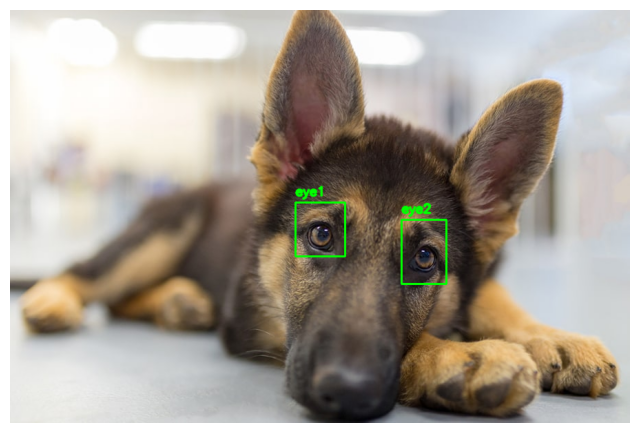

In [6]:
img=cr.image_operations.io.load_image("../assets/g.jpg")
bboxes=[bbox3,bbox4]
labels=["eye1","eye2"]
cr.plot_operations.plot.bbox(image=img,bboxes=bboxes,labels=labels )

### `segment()`

**Purpose**
Overlay color-coded segmentation masks and annotations onto an image.

**Parameters**
- image : numpy.ndarray, str, or pathlib.Path
       - Input image (2D grayscale, 3D RGB, or 3D RGBA).
- masks : list or tuple of (numpy.ndarray, str, or pathlib.Path)
       - Sequence of 2D binary segmentation masks matching the image dimensions.
- labels : list or tuple of str
       - Text labels matching each mask in the `masks` sequence.
- bbox_flag : bool, optional
       - If True, draws bounding boxes around segmented objects. Default is False.



**Demonstration**

For masks , i have extracted the value for cordinate from the `labelme` Annotation tool.
- Therfefore i will using the masks values by importing the json through the json file of the image.

In [7]:
with open("../assets/g.json") as f:
    bbox_data=json.load(f)

In [8]:
bbox_data.keys()

dict_keys(['version', 'flags', 'shapes', 'imagePath', 'imageData', 'imageHeight', 'imageWidth'])

In [9]:
print(bbox_data["shapes"][0])
print(bbox_data["shapes"][1])

{'label': 'eye1', 'points': [[467.1328671328672, 311.8881118881119], [444.0559440559441, 305.5944055944056], [444.0559440559441, 305.5944055944056], [444.0559440559441, 305.5944055944056], [427.97202797202794, 317.4825174825175], [430.06993006993014, 341.2587412587413], [453.8461538461539, 352.4475524475525], [472.72727272727275, 337.76223776223776]], 'group_id': None, 'description': '', 'shape_type': 'polygon', 'flags': {}, 'mask': None}
{'label': 'eye2', 'points': [[591.6083916083917, 344.75524475524475], [616.0839160839162, 340.5594405594406], [625.1748251748252, 367.83216783216784], [595.1048951048951, 387.4125874125874], [575.5244755244755, 371.32867132867136]], 'group_id': None, 'description': '', 'shape_type': 'polygon', 'flags': {}, 'mask': None}


In [10]:
print(type(bbox_data))
print(type(bbox_data["shapes"]))
print(len(bbox_data["shapes"]))

<class 'dict'>
<class 'list'>
2


In [11]:
print(type(bbox_data["shapes"][0]["points"]))

<class 'list'>


- Extract all the points for the all the respective objects's mask in the image
- convert these points which have type<list> to numpy array that too having dtype as int because  opencv accpets only numpy array with int elements 

In [12]:
#point 1 for eye1
points_eye1=bbox_data["shapes"][0]["points"]
polygon = np.array(points_eye1, np.int32)
print(polygon.shape)
print(type(polygon))
print(polygon)

(8, 2)
<class 'numpy.ndarray'>
[[467 311]
 [444 305]
 [444 305]
 [444 305]
 [427 317]
 [430 341]
 [453 352]
 [472 337]]


In [13]:
points_eye2=bbox_data["shapes"][1]["points"]
polygon2 = np.array(points_eye2, np.int32)
polygon2 = polygon2.reshape((-1,1,2))
print(polygon2.shape)
print(type(polygon2))
print(polygon2)

(5, 1, 2)
<class 'numpy.ndarray'>
[[[591 344]]

 [[616 340]]

 [[625 367]]

 [[595 387]]

 [[575 371]]]


Now , the mask has to be created whose `H x W` has to be  same as the `H  x W` of the original image 
- The original image's height and width can be extracted from the data of the json file of the image.

In [14]:
mask_eye1 = np.zeros((bbox_data["imageHeight"],bbox_data["imageWidth"]),np.uint8)
print(mask_eye1.shape)

(600, 900)


In [15]:
#eye 2 mask
mask_eye2 = np.zeros((bbox_data["imageHeight"],bbox_data["imageWidth"]),np.uint8)

In [16]:
np.unique(mask_eye1)

array([0], dtype=uint8)

- Currently the polygon shape is  - (8,2)
- OpenCV wants : (8,1,2)
- So polygon need to be reshaped to (-1,1,2)

In [17]:
polygon=polygon.reshape((-1,1,2))
polygon.shape

(8, 1, 2)

Now to the mask created , it need to get filled for the pixels where the actual object lies by using the polygon extracted from the json file

In [18]:
cv2.fillPoly(mask_eye1,[polygon],color=255)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [19]:
cv2.fillPoly(mask_eye2,[polygon2],color=255)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [20]:
type(mask_eye1)

numpy.ndarray

In [21]:
cr.image_operations.io.save_image("../assets/mask_eye1.png",mask_eye1)

True

In [22]:
cr.image_operations.io.save_image("../assets/mask_eye2.png",mask_eye2)

True

In [23]:
np.unique(mask_eye1)

array([  0, 255], dtype=uint8)

In [24]:
np.unique(mask_eye2)

array([  0, 255], dtype=uint8)

In [28]:
masks = [mask_eye1, mask_eye2]
labels = [bbox_data["shapes"][0]["label"], bbox_data["shapes"][1]["label"]]

In [29]:
import matplotlib.pyplot as plt

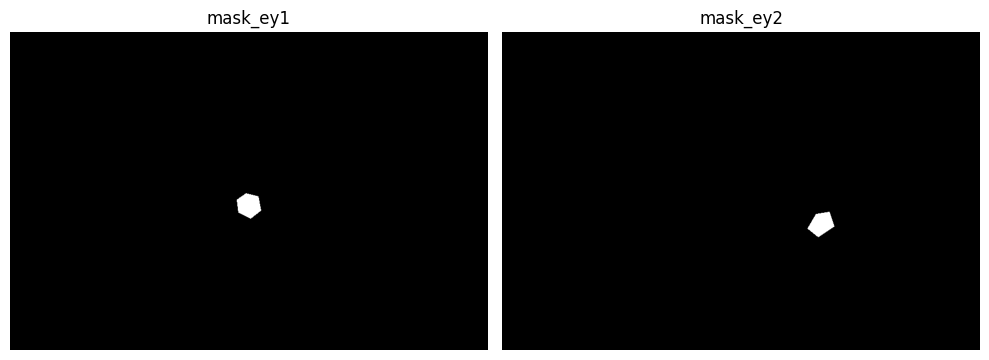

In [30]:
cr.plot_operations.image_row(mask_ey1=mask_eye1,mask_ey2=mask_eye2)

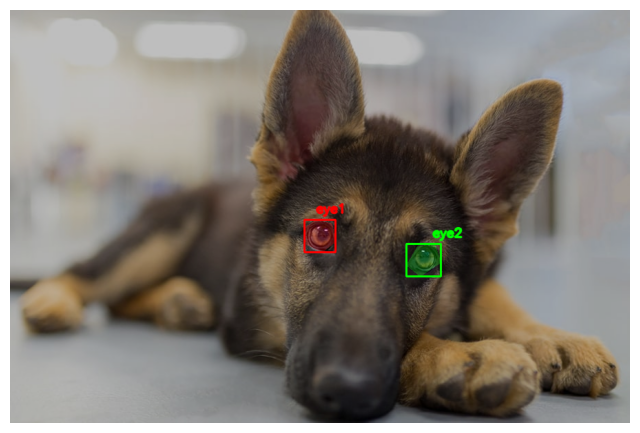

In [32]:
cr.plot_operations.plot.segment(image=img,masks=masks,labels=labels,bbox_flag=True)

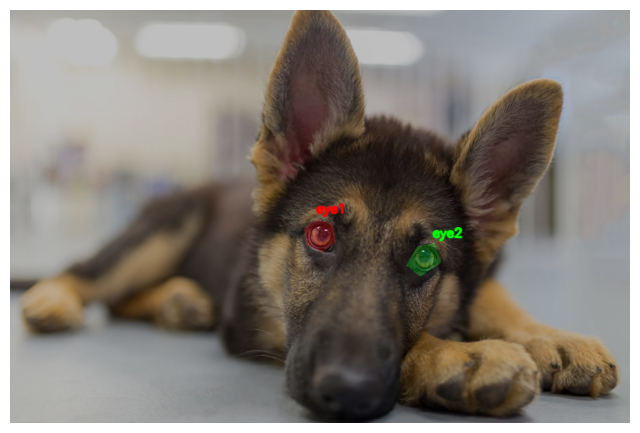

In [33]:
cr.plot_operations.plot.segment(image=img,masks=masks,labels=labels,bbox_flag=False)